In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
# # Specify your remote directory
HOME = '/content/drive/MyDrive/yeast'

#HOME = '/content/drive/MyDrive/skbio-ismb-2024/'

In [4]:
!ls $HOME

tabla_final.tsv


In [5]:
!head $HOME/tabla_final.tsv| cut -c1-100

sample	strain	reads	analysis	group	country
40_Melli	AAR	2	cov_AAR_vs_ADE	10. Mosaic beer	Ireland
40_Melli	ADE	0	cov_AAR_vs_ADE	12. Mexican distillery/agave	Aba, Abia State, Nigeria
41_Melli	AAR	1	cov_AAR_vs_ADE	10. Mosaic beer	Ireland
41_Melli	ADE	0	cov_AAR_vs_ADE	12. Mexican distillery/agave	Aba, Abia State, Nigeria
46_Melli	AAR	0	cov_AAR_vs_ADE	10. Mosaic beer	Ireland
46_Melli	ADE	0	cov_AAR_vs_ADE	12. Mexican distillery/agave	Aba, Abia State, Nigeria
47_Melli	AAR	1	cov_AAR_vs_ADE	10. Mosaic beer	Ireland
47_Melli	ADE	0	cov_AAR_vs_ADE	12. Mexican distillery/agave	Aba, Abia State, Nigeria
51_Scapto	AAR	5	cov_AAR_vs_ADE	10. Mosaic beer	Ireland


In [6]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# =========================
# CONFIG
# =========================
INPUT_TSV = f'{HOME}/tabla_final.tsv'
OUTPUT_DIR = "heatmaps_por_muestra"
USE_GLOBAL_SCALE = False   # False = escala por muestra; True = una sola escala para todas las muestras
FIG_DPI = 220
CMAP_NAME = "viridis"


In [7]:

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(INPUT_TSV, sep="\t")

required_cols = {"sample", "strain", "reads", "analysis"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

df["reads"] = pd.to_numeric(df["reads"], errors="coerce").fillna(0)

# =========================


In [8]:
print(df.head())

     sample strain  reads        analysis                         group  \
0  40_Melli    AAR      2  cov_AAR_vs_ADE               10. Mosaic beer   
1  40_Melli    ADE      0  cov_AAR_vs_ADE  12. Mexican distillery/agave   
2  41_Melli    AAR      1  cov_AAR_vs_ADE               10. Mosaic beer   
3  41_Melli    ADE      0  cov_AAR_vs_ADE  12. Mexican distillery/agave   
4  46_Melli    AAR      0  cov_AAR_vs_ADE               10. Mosaic beer   

                    country  
0                   Ireland  
1  Aba, Abia State, Nigeria  
2                   Ireland  
3  Aba, Abia State, Nigeria  
4                   Ireland  


In [9]:
df.shape

(4080, 6)

In [10]:
print(df.shape)

(4080, 6)


In [11]:
# =========================
# PARSE ANALYSIS NAME
# Espera algo como: cov_BLD_sake
# =========================
def parse_analysis_pair(analysis_name: str):
    print(str(analysis_name))
    m = re.match(r"^cov_(.+)_(.+)$", str(analysis_name))
    if not m:
        return None, None
    return m.group(1), m.group(2)

pair_map = {}
all_participant_strains = set()

for a in sorted(df["analysis"].unique()):
    s1, s2 = parse_analysis_pair(a)
    pair_map[a] = (s1, s2)
    if s1 is not None:
        all_participant_strains.add(s1)
    if s2 is not None:
        all_participant_strains.add(s2)

# También incluimos cualquier strain que aparezca en los datos
all_strains = sorted(set(df["strain"].unique()) | all_participant_strains)

# Orden opcional: poner "sake" al final o al principio
def sort_key(x):
    if x == "sake":
        return (1, x)
    return (0, x)

all_strains = sorted(all_strains, key=sort_key)

all_analyses = sorted(df["analysis"].unique())

#


cov_AAR_vs_ADE
cov_AAR_vs_AEG
cov_AAR_vs_AGK
cov_AAR_vs_AHL
cov_AAR_vs_ATV
cov_AAR_vs_BLD_1a
cov_AAR_vs_L1374
cov_AAR_vs_SK1
cov_AAR_vs_SX2
cov_AAR_vs_W303
cov_AAR_vs_Y12
cov_AAR_vs_YPS128
cov_AAR_vs_ZP568s1
cov_AAR_vs_sake
cov_AAR_vs_scer
cov_ADE_vs_AEG
cov_ADE_vs_AGK
cov_ADE_vs_AHL
cov_ADE_vs_ATV
cov_ADE_vs_BLD_1a
cov_ADE_vs_L1374
cov_ADE_vs_SK1
cov_ADE_vs_SX2
cov_ADE_vs_W303
cov_ADE_vs_Y12
cov_ADE_vs_YPS128
cov_ADE_vs_ZP568s1
cov_ADE_vs_sake
cov_ADE_vs_scer
cov_AEG_vs_AGK
cov_AEG_vs_AHL
cov_AEG_vs_ATV
cov_AEG_vs_BLD_1a
cov_AEG_vs_L1374
cov_AEG_vs_SK1
cov_AEG_vs_SX2
cov_AEG_vs_W303
cov_AEG_vs_Y12
cov_AEG_vs_YPS128
cov_AEG_vs_ZP568s1
cov_AEG_vs_sake
cov_AEG_vs_scer
cov_AGK_vs_AHL
cov_AGK_vs_ATV
cov_AGK_vs_BLD_1a
cov_AGK_vs_L1374
cov_AGK_vs_SK1
cov_AGK_vs_SX2
cov_AGK_vs_W303
cov_AGK_vs_Y12
cov_AGK_vs_YPS128
cov_AGK_vs_ZP568s1
cov_AGK_vs_sake
cov_AGK_vs_scer
cov_AHL_vs_ATV
cov_AHL_vs_BLD_1a
cov_AHL_vs_L1374
cov_AHL_vs_SK1
cov_AHL_vs_SX2
cov_AHL_vs_W303
cov_AHL_vs_Y12
cov_AHL_vs_YPS128
c

In [12]:
len(all_analyses)
len(all_strains)
len(all_participant_strains)
len(df["analysis"].unique())

120

In [13]:
    #global_vmax = None

In [14]:
# =========================
# OUTPUT DIR
# =========================
os.makedirs(OUTPUT_DIR, exist_ok=True)



In [26]:
# =========================
# PLOT FUNCTION
# =========================
def plot_sample_heatmap(sample_df, sample_name, all_strains, all_analyses, pair_map, output_dir,
                        cmap_name="viridis", vmax=None, dpi=220):
    """
    Hace un heatmap por muestra:
    - filas = strains
    - columnas = analyses
    - color = reads
    - solo se rellenan las dos referencias participantes de cada prueba
    - se dibuja borde más grueso en las dos celdas de esa comparación
    """

    # matriz con NaN para no participantes
    mat = pd.DataFrame(np.nan, index=all_strains, columns=all_analyses, dtype=float)

    # llenar solo las celdas existentes
    for _, row in sample_df.iterrows():
        strain = row["strain"]
        analysis = row["analysis"]
        reads = row["reads"]
        if strain in mat.index and analysis in mat.columns:
            mat.loc[strain, analysis] = reads

    # escala
    if vmax is None:
        this_vmax = np.nanmax(mat.values)
        if np.isnan(this_vmax) or this_vmax == 0:
            this_vmax = 1
    else:
        this_vmax = vmax

    norm = Normalize(vmin=0, vmax=this_vmax)
    cmap = cm.get_cmap(cmap_name)

    n_rows = len(all_strains)
    n_cols = len(all_analyses)

    # tamaño dinámico
    fig_w = max(7, n_cols * 1.15)
    fig_h = max(5, n_rows * 0.5)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # fondo gris claro para toda la matriz
    ax.set_facecolor("white")

    # dibujar celdas una por una
    for i, strain in enumerate(all_strains):
        for j, analysis in enumerate(all_analyses):
            value = mat.loc[strain, analysis]

            # participantes de esta comparación
            p1, p2 = pair_map.get(analysis, (None, None))
            is_participant = strain in {p1, p2}

            if pd.notna(value):
                facecolor = cmap(norm(value))
            else:
                # no participante / no valor
                facecolor = (0.96, 0.96, 0.96, 1.0)

            # borde normal
            edgecolor = (0.82, 0.82, 0.82, 1.0)
            linewidth = 0.8

            # borde destacado si esa strain participa en esa comparación
            if is_participant:
                edgecolor = "black"
                linewidth = 2.0

            rect = Rectangle((j, i), 1, 1,
                             facecolor=facecolor,
                             edgecolor=edgecolor,
                             linewidth=linewidth)
            ax.add_patch(rect)

            # anotar reads solo en participantes con valor
            if pd.notna(value):
                txt = f"{int(value)}"
                # color del texto según intensidad
                text_color = "white" if norm(value) > 0.55 else "black"
                ax.text(j + 0.5, i + 0.5, txt,
                        ha="center", va="center",
                        fontsize=8, color=text_color)

    # ejes
    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_xticklabels(all_analyses, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(all_strains, fontsize=10)
    ax.tick_params(axis='y', pad=6)


    # título
    ax.set_title(f"Muestra: {sample_name}\nReads absolutos por mapeo competitivo", fontsize=13, pad=16)

    # quitar bordes del plot
    for spine in ax.spines.values():
        spine.set_visible(False)

    # colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Reads", fontsize=10)

    plt.tight_layout()

    safe_sample = re.sub(r"[^A-Za-z0-9._-]+", "_", str(sample_name))
    out_png = os.path.join(output_dir, f"{safe_sample}_heatmap.png")
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight")
    plt.close(fig)

    return out_png



In [16]:
# =========================
# GENERATE ALL HEATMAPS
# =========================
saved_files = []
global_vmax=10000

for sample_name, sample_df in df.groupby("sample", sort=True):
    out = plot_sample_heatmap(
        sample_df=sample_df,
        sample_name=sample_name,
        all_strains=all_strains,
        all_analyses=all_analyses,
        pair_map=pair_map,
        output_dir=OUTPUT_DIR,
        cmap_name=CMAP_NAME,
        vmax=global_vmax,
        dpi=FIG_DPI
    )
    saved_files.append(out)

print(f"Se generaron {len(saved_files)} heatmaps en: {OUTPUT_DIR}")
for f in saved_files[:5]:
    print(f)

/tmp/ipykernel_4802/3390475982.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/tmp/ipykernel_4802/3390475982.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/tmp/ipykernel_4802/3390475982.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/tmp/ipykernel_4802/3390475982.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 a

Se generaron 17 heatmaps en: heatmaps_por_muestra
heatmaps_por_muestra/40_Melli_heatmap.png
heatmaps_por_muestra/41_Melli_heatmap.png
heatmaps_por_muestra/46_Melli_heatmap.png
heatmaps_por_muestra/47_Melli_heatmap.png
heatmaps_por_muestra/51_Scapto_heatmap.png


In [17]:
# =========================
# GENERATE ALL HEATMAPS
# =========================
saved_files = []

# máximo de reads por muestra
sample_max_dict = df.groupby("sample")["reads"].max().to_dict()

for sample_name, sample_df in df.groupby("sample", sort=True):
    sample_vmax = sample_max_dict.get(sample_name, 1)

    out = plot_sample_heatmap(
        sample_df=sample_df,
        sample_name=sample_name,
        all_strains=all_strains,
        all_analyses=all_analyses,
        pair_map=pair_map,
        output_dir=OUTPUT_DIR,
        cmap_name=CMAP_NAME,
        vmax=sample_vmax,
        dpi=FIG_DPI
    )
    saved_files.append(out)

print(f"Se generaron {len(saved_files)} heatmaps en: {OUTPUT_DIR}")
for f in saved_files[:5]:
    print(f)

/tmp/ipykernel_4802/3390475982.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/tmp/ipykernel_4802/3390475982.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7faa6db08fe0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7faa6dcde520> (for post_execute):


KeyboardInterrupt: 

/tmp/ipykernel_4802/1947201979.py:183: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(CMAP_NAME)


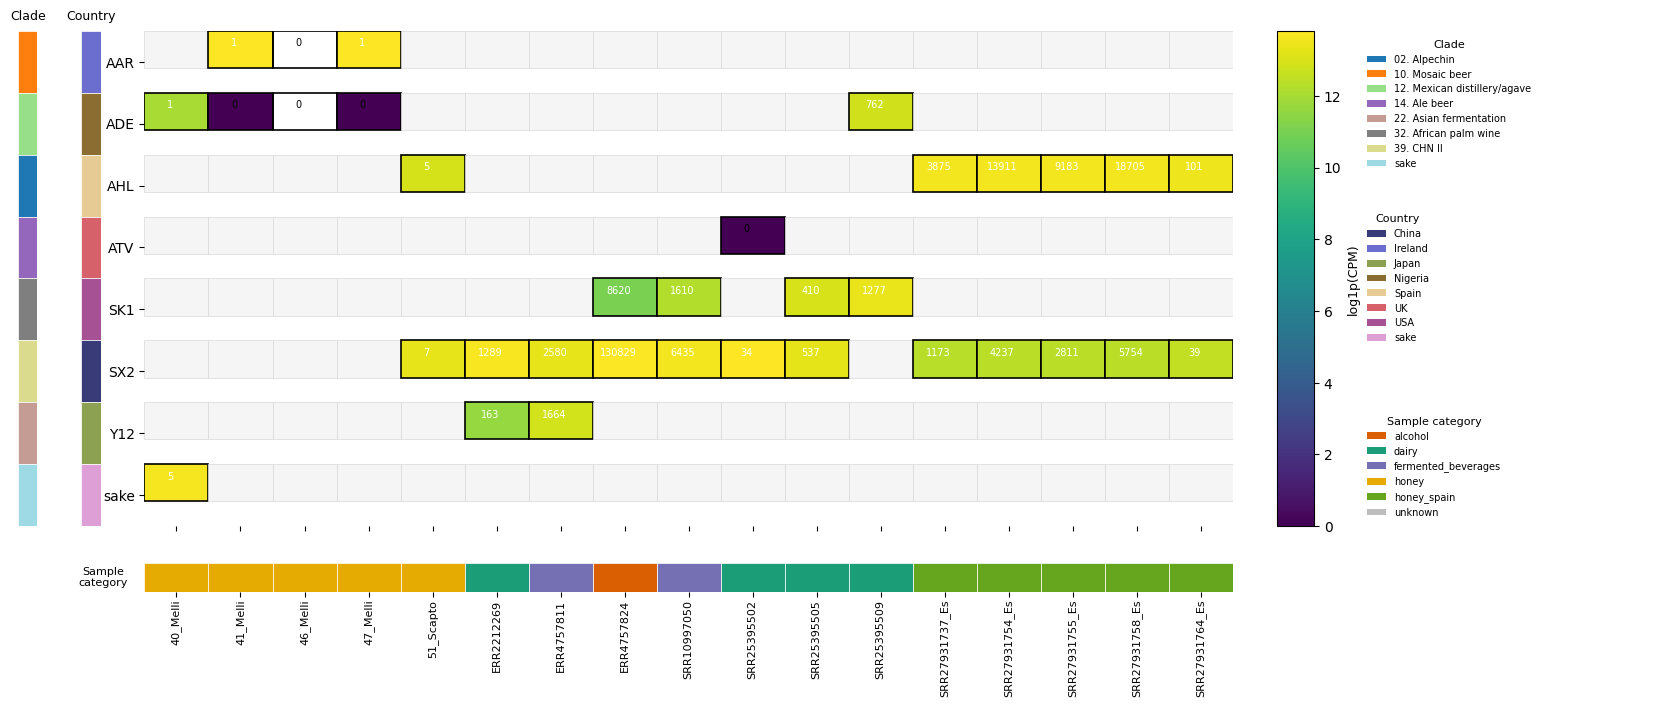

Guardado en: heatmap_global_best_per_sample_log_cpm_annotated.png


In [38]:
# =========================
# GLOBAL HEATMAP (one column per sample, using best analysis)
# - collapse *_vs* strains into base strain
# - normalize per sample as CPM
# - color scale uses log1p(CPM)
# - text shows raw reads
# - add left annotation bars for clade and country
# - add bottom annotation bar for sample category
# - show sample names clearly
# - include visible legends for clade and country
# =========================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# ============================================================
# 0. METADATA
# ============================================================

STRAIN_CLADE = {
    "AGK": "17. Mixed origin 1",
    "AHL": "02. Alpechin",
    "AEG": "04. Brazilian bioethanol",
    "ATV": "14. Ale beer",
    "AAR": "10. Mosaic beer",
    "BLD_1a": "01. Wine European 1",
    "L1374": "01. Wine European 1",
    "ADE": "12. Mexican distillery/agave",
    "SK1": "32. African palm wine",
    "SX2": "39. CHN II",
    "W303": "13. Lab-related",
    "Y12": "22. Asian fermentation",
    "YPS128": "28. North American",
    "ZP568s1": "09. Mediterranean oak",
    "sake": "sake",
}

STRAIN_COUNTRY = {
    "AGK": "UK",
    "AHL": "Spain",
    "AEG": "Brazil",
    "ATV": "UK",
    "AAR": "Ireland",
    #"BLD_1a": "La Mancha, Spain",
    "BLD_1a": "Spain",
    #"L1374": "Cauquenes, Chile",
    "L1374": "Chile",
    #"ADE": "Aba, Abia State, Nigeria",
    "ADE": "Nigeria",
    "SK1": "USA",
    #"SX2": "Qinling Mountain, Shaanxi, China",
    "SX2": "China",
    "W303": "USA",
    "Y12": "Japan",
    #"YPS128": "Pennsylvania, USA",
    "YPS128": "USA",
    #"ZP568s1": "Castelo de Vide, Portugal",
    "ZP568s1": "Portugal",
    "sake": "sake",
}

SAMPLE_CATEGORY_MAP = {
    "ERR2756685": "alcohol",
    "DRR205702": "alcohol",
    "ERR4757824": "alcohol",
    "SRR27593174": "alcohol",
    "SRR3017090": "alcohol",
    "SRR25395509": "dairy",
    "SRR25395505": "dairy",
    "SRR25395502": "dairy",
    "ERR2212269": "dairy",
    "SRR28523165": "dairy",
    "ERR1653130": "dairy",
    "ERR2126384": "fermented_beverages",
    "SRR10997050": "fermented_beverages",
    "ERR4757811": "fermented_beverages",
}

SAMPLE_CATEGORY_COLORS = {
    "alcohol": "#d95f02",
    "dairy": "#1b9e77",
    "fermented_beverages": "#7570b3",
    "honey": "#e6ab02",
    "honey_spain": "#66a61e",
    "unknown": "#bdbdbd",
}

# ============================================================
# 1. HELPERS
# ============================================================

def clean_strain_name(strain: str) -> str:
    strain = str(strain)
    return re.sub(r"_vs.*$", "", strain)

def get_clade(strain: str) -> str:
    return STRAIN_CLADE.get(strain, "Unknown")

def get_country(strain: str) -> str:
    return STRAIN_COUNTRY.get(strain, "Unknown")

def get_sample_category(sample: str) -> str:
    sample = str(sample)

    if sample in SAMPLE_CATEGORY_MAP:
        return SAMPLE_CATEGORY_MAP[sample]

    sample_lower = sample.lower()

    if ("melli" in sample_lower) or ("scapt" in sample_lower):
        return "honey"

    if "_es" in sample_lower:
        return "honey_spain"

    return "unknown"

def make_color_map(labels, cmap_name="tab20"):
    labels = list(labels)
    cmap_obj = plt.get_cmap(cmap_name, max(len(labels), 1))
    return {lab: cmap_obj(i) for i, lab in enumerate(labels)}

# ============================================================
# 2. PREPARE DATA
# ============================================================

df_plot = df.copy()
df_plot["strain_clean"] = df_plot["strain"].astype(str).map(clean_strain_name)

best_per_sample = []

for sample_name, sample_df in df_plot.groupby("sample", sort=True):
    analysis_totals = (
        sample_df.groupby("analysis", as_index=False)["reads"]
        .sum()
        .sort_values("reads", ascending=False)
    )

    if analysis_totals.empty:
        continue

    best_analysis = analysis_totals.iloc[0]["analysis"]
    best_df = sample_df[sample_df["analysis"] == best_analysis].copy()

    best_df = (
        best_df.groupby(["sample", "strain_clean", "analysis"], as_index=False)["reads"]
        .sum()
    )
    best_df["best_analysis"] = best_analysis
    best_per_sample.append(best_df)

if not best_per_sample:
    raise ValueError("No se encontraron datos para construir el heatmap global.")

best_df_all = pd.concat(best_per_sample, ignore_index=True)

samples = sorted(best_df_all["sample"].unique())
strains = sorted(best_df_all["strain_clean"].unique())

mat_raw = pd.DataFrame(np.nan, index=strains, columns=samples)

for _, row in best_df_all.iterrows():
    mat_raw.loc[row["strain_clean"], row["sample"]] = row["reads"]

# ============================================================
# 3. NORMALIZATION
# ============================================================

col_sums = mat_raw.sum(axis=0, skipna=True).replace(0, np.nan)
mat_cpm = mat_raw.div(col_sums, axis=1) * 1e6
mat_plot = np.log1p(mat_cpm)

vmax = np.nanmax(mat_plot.values)
if pd.isna(vmax) or vmax == 0:
    vmax = 1

norm = Normalize(vmin=0, vmax=vmax)
cmap = cm.get_cmap(CMAP_NAME)

# ============================================================
# 4. ANNOTATION COLOR MAPS
# ============================================================

clades = [get_clade(s) for s in strains]
countries = [get_country(s) for s in strains]
sample_categories = [get_sample_category(s) for s in samples]

unique_clades = sorted(set(clades))
unique_countries = sorted(set(countries))
unique_sample_categories = sorted(set(sample_categories))

clade_colors = make_color_map(unique_clades, "tab20")
country_colors = make_color_map(unique_countries, "tab20b")

# ============================================================
# 5. PLOT LAYOUT
# ============================================================

n_rows = len(strains)
n_cols = len(samples)

fig_w = max(14, n_cols * 0.58 + 10.0)
fig_h = max(8.5, n_rows * 0.42 + 4.2)

fig = plt.figure(figsize=(fig_w, fig_h))
gs = fig.add_gridspec(
    nrows=2,
    ncols=5,
    width_ratios=[0.18, 0.18, max(10, n_cols * 0.6), 0.35, 2.8],
    height_ratios=[max(6, n_rows * 0.42), 0.35],
    wspace=0.15,
    hspace=0.14,
)

ax_clade = fig.add_subplot(gs[0, 0])
ax_country = fig.add_subplot(gs[0, 1])
ax = fig.add_subplot(gs[0, 2])
ax_cbar = fig.add_subplot(gs[0, 3])
ax_leg = fig.add_subplot(gs[0, 4])
ax_cat = fig.add_subplot(gs[1, 2])

# ============================================================
# 6. LEFT ANNOTATION BARS: CLADE + COUNTRY
# ============================================================

for i, strain in enumerate(strains):
    clade = get_clade(strain)
    country = get_country(strain)

    ax_clade.add_patch(Rectangle((0, i), 1, 1,
                                 facecolor=clade_colors.get(clade, "#d9d9d9"),
                                 edgecolor="white", linewidth=0.5))
    ax_country.add_patch(Rectangle((0, i), 1, 1,
                                   facecolor=country_colors.get(country, "#d9d9d9"),
                                   edgecolor="white", linewidth=0.5))

for ax_ann, title in [(ax_clade, "Clade"), (ax_country, "Country")]:
    ax_ann.set_xlim(0, 1)
    ax_ann.set_ylim(n_rows, 0)
    ax_ann.set_xticks([])
    ax_ann.set_yticks([])
    ax_ann.set_title(title, fontsize=9, pad=8)
    for spine in ax_ann.spines.values():
        spine.set_visible(False)

# ============================================================
# 7. MAIN HEATMAP
# ============================================================

for i, strain in enumerate(strains):
    for j, sample in enumerate(samples):
        raw_value = mat_raw.loc[strain, sample]
        plot_value = mat_plot.loc[strain, sample]

        if pd.notna(raw_value):
            facecolor = cmap(norm(plot_value))
            edgecolor = "black"
            linewidth = 1.2
        else:
            facecolor = (0.96, 0.96, 0.96, 1)
            edgecolor = (0.85, 0.85, 0.85, 1)
            linewidth = 0.5

        ax.add_patch(
            Rectangle(
                (j, i), 1, 0.6,
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=linewidth
            )
        )

        if pd.notna(raw_value):
            txt_color = "white" if norm(plot_value) > 0.60 else "black"
            ax.text(
                j + 0.4, i + 0.2, f"{int(raw_value)}",
                ha="center", va="center",
                fontsize=7, color=txt_color
            )

ax.set_xlim(0, n_cols)
ax.set_ylim(n_rows, 0)
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels([])  # labels go on the category bar below
ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels(strains, fontsize=10)

for spine in ax.spines.values():
    spine.set_visible(False)

# ============================================================
# 8. COLORBAR
# ============================================================

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label("log1p(CPM)", fontsize=9)

# ============================================================
# 9. BOTTOM ANNOTATION BAR: SAMPLE CATEGORY + SAMPLE NAMES
# ============================================================

for j, sample in enumerate(samples):
    category = get_sample_category(sample)
    color = SAMPLE_CATEGORY_COLORS.get(category, SAMPLE_CATEGORY_COLORS["unknown"])
    ax_cat.add_patch(
        Rectangle((j, 0), 1, 1, facecolor=color, edgecolor="white", linewidth=0.5)
    )

ax_cat.set_xlim(0, n_cols)
ax_cat.set_ylim(0.6, 0)
ax_cat.set_xticks(np.arange(n_cols) + 0.5)
ax_cat.set_xticklabels(samples, rotation=90, fontsize=8)
ax_cat.tick_params(axis="x", bottom=True, labelbottom=True, pad=2)
ax_cat.set_yticks([])
ax_cat.set_ylabel("Sample\ncategory", fontsize=8, rotation=0, labelpad=30, va="center")

for spine in ax_cat.spines.values():
    spine.set_visible(False)

# ============================================================
# 10. LEGENDS IN A SEPARATE AXIS
# ============================================================

from matplotlib.patches import Patch

ax_leg.axis("off")

# --- Clade legend
clade_patches = [
    Patch(facecolor=color, label=clade)
    for clade, color in clade_colors.items()
]

leg1 = ax_leg.legend(
    handles=clade_patches,
    title="Clade",
    loc="upper left",
    fontsize=7,
    title_fontsize=8,
    frameon=False
)
ax_leg.add_artist(leg1)

# --- Country legend
country_patches = [
    Patch(facecolor=color, label=country)
    for country, color in country_colors.items()
]

leg2 = ax_leg.legend(
    handles=country_patches,
    title="Country",
    loc="center left",
    fontsize=7,
    title_fontsize=8,
    frameon=False
)
ax_leg.add_artist(leg2)

# --- Sample category legend
sample_patches = [
    Patch(facecolor=color, label=cat)
    for cat, color in SAMPLE_CATEGORY_COLORS.items()
]

leg3 = ax_leg.legend(
    handles=sample_patches,
    title="Sample category",
    loc="lower left",
    fontsize=7,
    title_fontsize=8,
    frameon=False
)


plt.subplots_adjust(bottom=0.22, right=0.95)
out_png = "heatmap_global_best_per_sample_log_cpm_annotated.png"
plt.savefig(out_png, dpi=FIG_DPI, bbox_inches="tight")
plt.show()

print(f"Guardado en: {out_png}")
